# Music recommendation based on genre, mode, tempo using ML pipeline, evaluation and Hyperparameter tuning

### Prepared by: Udita Bose <uditab@student.unimelb.edu.au>

In [1]:
# import numpy, pandas, graphs
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import scikit libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    RobustScaler,
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    validation_curve,
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest
)

from sklearn.pipeline import Pipeline


In [3]:
# import kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [4]:
# load the dataset in a Panda DataFrame
all_music_data_df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vicsuperman/prediction-of-music-genre",
    "music_genre.csv"
)


### Initial Data Exploration

In [5]:
# first few rows
all_music_data_df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [6]:
# basic statistics
# all_music_data_df = all_music_data_df.drop(columns=["instance_id"])
all_music_data_df.head()
all_music_data_df.describe()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,valence
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,55888.396360,44.220420,0.306383,0.558241,2.212526e+05,0.599755,0.181601,0.193896,-9.133761,0.093586,0.456264
std,20725.256253,15.542008,0.341340,0.178632,1.286720e+05,0.264559,0.325409,0.161637,6.162990,0.101373,0.247119
min,20002.000000,0.000000,0.000000,0.059600,-1.000000e+00,0.000792,0.000000,0.009670,-47.046000,0.022300,0.000000
25%,37973.500000,34.000000,0.020000,0.442000,1.748000e+05,0.433000,0.000000,0.096900,-10.860000,0.036100,0.257000
50%,55913.500000,45.000000,0.144000,0.568000,2.192810e+05,0.643000,0.000158,0.126000,-7.276500,0.048900,0.448000
75%,73863.250000,56.000000,0.552000,0.687000,2.686122e+05,0.815000,0.155000,0.244000,-5.173000,0.098525,0.648000
max,91759.000000,99.000000,0.996000,0.986000,4.830606e+06,0.999000,0.996000,1.000000,3.744000,0.942000,0.992000


In [7]:
# correlations existing in the raw data
all_correlation = all_music_data_df.corr(method="pearson", numeric_only=True)
print(f"Correlation of all data: {all_correlation}")

Correlation of all data:                   instance_id  popularity  acousticness  danceability  \
instance_id          1.000000    0.006317     -0.005268      0.000372   
popularity           0.006317    1.000000     -0.290453      0.356420   
acousticness        -0.005268   -0.290453      1.000000     -0.347681   
danceability         0.000372    0.356420     -0.347681      1.000000   
duration_ms         -0.005848   -0.083809      0.061862     -0.155507   
energy               0.009952    0.216345     -0.791250      0.263934   
instrumentalness    -0.004015   -0.364960      0.387970     -0.301277   
liveness             0.004737   -0.039468     -0.109220     -0.051465   
loudness             0.006847    0.317941     -0.730401      0.390859   
speechiness         -0.005908    0.224309     -0.163377      0.279767   
valence              0.005385    0.124913     -0.270238      0.434557   

                  duration_ms    energy  instrumentalness  liveness  loudness  \
instance_id      

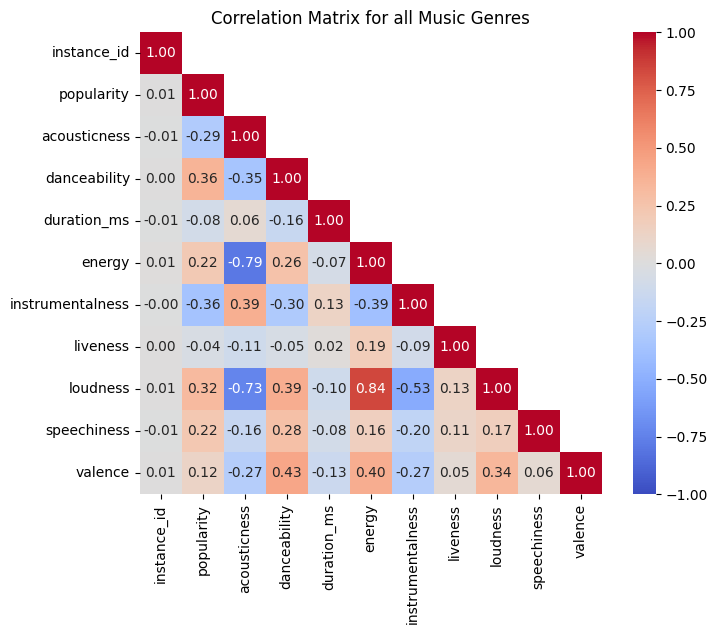

In [8]:
# correlation plotted
mask = np.triu(np.ones_like(all_correlation, dtype=float), k=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(all_correlation, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix for all Music Genres")
plt.show()

In [9]:
# data shape
all_music_data_df.shape

(50005, 18)

In [10]:
# columns, and data types
all_music_data_df.dtypes

instance_id         float64
artist_name             str
track_name              str
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                     str
liveness            float64
loudness            float64
mode                    str
speechiness         float64
tempo                   str
obtained_date           str
valence             float64
music_genre             str
dtype: object

In [11]:
# raw data per genre
all_music_data_df['music_genre'].value_counts()

music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64

In [12]:
# unavailable data per feature
all_music_data_df.isna().sum()

instance_id         5
artist_name         5
track_name          5
popularity          5
acousticness        5
danceability        5
duration_ms         5
energy              5
instrumentalness    5
key                 5
liveness            5
loudness            5
mode                5
speechiness         5
tempo               5
obtained_date       5
valence             5
music_genre         5
dtype: int64

In [13]:
# unique data for string columns
columns = ['key','mode','tempo']
for column in columns:
    print(f"    {column}: {all_music_data_df[column].unique()}")
    print()

    key: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str

    mode: <StringArray>
['Minor', 'Major', nan]
Length: 3, dtype: str

    tempo: <StringArray>
[           '100.889', '115.00200000000001',            '127.994',
            '128.014',            '145.036',                  '?',
            '149.995',            '120.008', '149.94799999999998',
            '139.933',
 ...
            '175.903',             '93.758',             '83.881',
            '128.194',            '138.964',            '129.939',
            '129.285',             '112.97',            '167.655',
  '99.20100000000001']
Length: 29395, dtype: str



In [14]:
# find any duplicated data
duplicated = all_music_data_df.duplicated()
print(f"duplicated : {all_music_data_df[duplicated]}")

duplicated :        instance_id artist_name track_name  popularity  acousticness  \
10001          NaN         NaN        NaN         NaN           NaN   
10002          NaN         NaN        NaN         NaN           NaN   
10003          NaN         NaN        NaN         NaN           NaN   
10004          NaN         NaN        NaN         NaN           NaN   

       danceability  duration_ms  energy  instrumentalness  key  liveness  \
10001           NaN          NaN     NaN               NaN  NaN       NaN   
10002           NaN          NaN     NaN               NaN  NaN       NaN   
10003           NaN          NaN     NaN               NaN  NaN       NaN   
10004           NaN          NaN     NaN               NaN  NaN       NaN   

       loudness mode  speechiness tempo obtained_date  valence music_genre  
10001       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10002       NaN  NaN          NaN   NaN           NaN      NaN         NaN  
10003       Na

In [15]:
only_mode_music = all_music_data_df[['track_name', 'mode', 'music_genre', 'popularity']]
only_mode_music.head()

,track_name,mode,music_genre,popularity
0,Röyksopp's Night Out,Minor,Electronic,27.0
1,The Shining Path,Minor,Electronic,31.0
2,Hurricane,Major,Electronic,28.0
3,Nitro,Major,Electronic,34.0
4,Divide & Conquer,Major,Electronic,32.0


## Visualize data

/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/205126863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each mode')

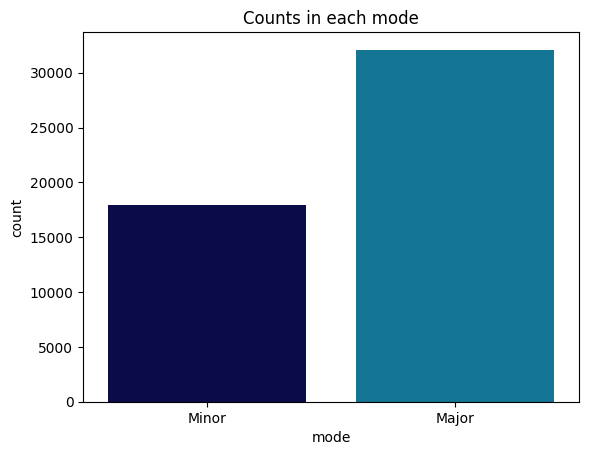

In [16]:
sns.countplot(x = 'mode', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each mode")


All keys: <StringArray>
['A#', 'D', 'G#', 'C#', 'F#', 'B', 'G', 'F', 'A', 'C', 'E', 'D#', nan]
Length: 13, dtype: str



/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/4043498728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)


Text(0.5, 1.0, 'Counts in each key')

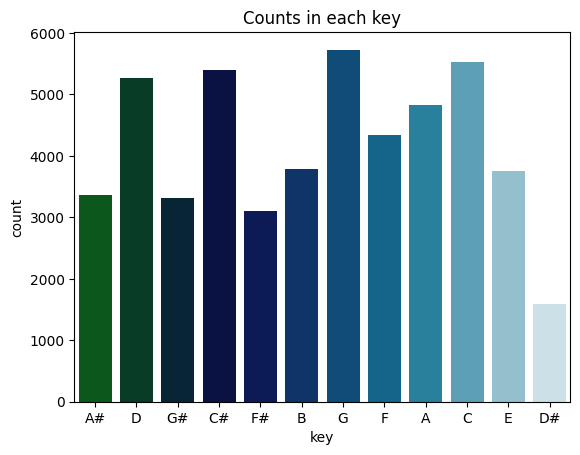

In [17]:
keys_of_music = all_music_data_df['key'].unique()
print(f"All keys: {keys_of_music}")
print()
sns.countplot(x = 'key', data = all_music_data_df, palette = "ocean", order = None)
plt.title(f"Counts in each key")

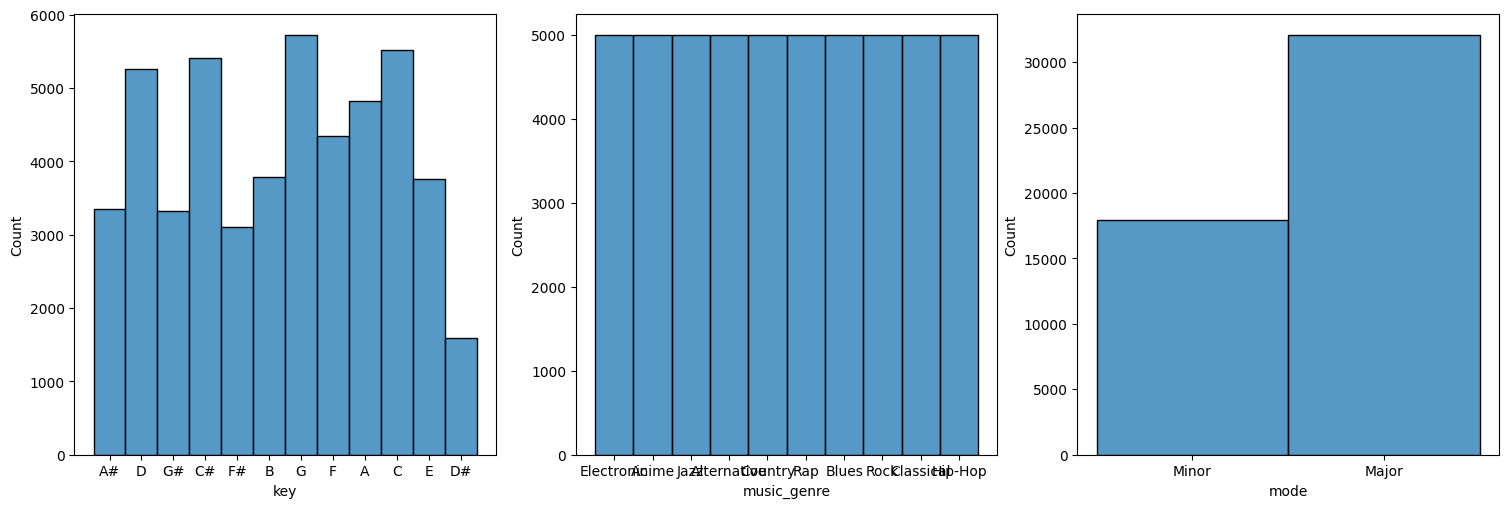

In [18]:
fig, axs = plt.subplots(ncols = 3, nrows = 1, figsize = (15, 5))
# fig.delaxes(axs[2][0])
index = 0

str_features = all_music_data_df[["key", "music_genre", "mode"]]

axs = axs.flatten()
for k, v in str_features.items():
    sns.histplot(v, ax = axs[index])
    index += 1
plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

In [19]:
numeric_features = all_music_data_df.drop(["key", "music_genre", "mode"], axis = 1)
fig, axs = plt.subplots(ncols = 3, nrows = 4, figsize = (15, 15))
fig.delaxes(axs[3][2])
index = 0

axs = axs.flatten()
for k, v in numeric_features.items():
    if index < 12:
        sns.histplot(v, ax = axs[index])
        index += 1
plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)

/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/3695052334.py:11: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)
/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/3695052334.py:11: UserWarning: Glyph 28843 (\N{CJK UNIFIED IDEOGRAPH-70AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)
/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/3695052334.py:11: UserWarning: Glyph 24561 (\N{CJK UNIFIED IDEOGRAPH-5FF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)
/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/3695052334.py:11: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad = 0.4, w_pad = 0.5, h_pad = 5.0)
/var/folders/1w/jl4qlcr169z42fh_0319qljh0000gn/T/ipykernel_52555/3695052334.py:11: Us

ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

Error in callback <function _draw_all_if_interactive at 0x10a30a0c0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

ValueError: 
Joey Bada$$
         ^
ParseException: Expected end of text, found '$'  (at char 9), (line:1, col:10)

<Figure size 1500x1500 with 11 Axes>

## Preprocess Data

### Copy Data for future usages, and drop bad data

In [20]:
# copy the data
processed_df = all_music_data_df.copy()
print(f"Initial data shape: {processed_df.shape}")

Initial data shape: (50005, 18)


In [21]:
# remove the columns that won't be used for any prediction
processed_df = processed_df.drop(['instance_id', 'artist_name', 'track_name', 'obtained_date'], axis=1)
print(f"Data shape after dropping columns: {processed_df.shape}")

Data shape after dropping columns: (50005, 14)


In [22]:
# drop rows with bad values, Thanks to Zed
bad_values = ['', ' ', '?' , -1 , '-1']
rows_to_drop = processed_df.isna() | processed_df.isin(bad_values)
processed_df = processed_df[~rows_to_drop.any(axis=1)]
print(f"Data shape after dropping bad data: {processed_df.shape}")

Data shape after dropping bad data: (40560, 14)


In [23]:
# drop duplicated rows, from Zed
duplicate_rows = processed_df.duplicated()
if duplicate_rows.sum() > 0:
    print(f"Duplicate rows: \n{processed_df[duplicate_rows]}")
    processed_df = processed_df.drop_duplicates().reset_index(drop=True)

print(f"Data shape after dropping duplicated data: {processed_df.shape}")

Duplicate rows: 
      popularity  acousticness  danceability  duration_ms  energy  \
2277        23.0         0.276         0.697     409400.0   0.389   

      instrumentalness key  liveness  loudness   mode  speechiness   tempo  \
2277             0.882   C     0.113   -13.733  Major       0.0412  87.694   

      valence music_genre  
2277    0.591  Electronic  
Data shape after dropping duplicated data: (40559, 14)


The basic pre-processing of the data has deleted
- 4 columns
- 9446 rows

### Encode the non-numeric features

In [24]:
# find the non-numeric columns
str_features = processed_df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Non-numeric features: {str_features}")

Non-numeric features: ['key', 'mode', 'tempo', 'music_genre']


In [25]:
# encode all the non-numeric columns with LabelEncoder
encoder_list = []
encoded_df = processed_df.copy()
for sf in str_features:
    sf_encoder = LabelEncoder()
    encoded_df[sf] = sf_encoder.fit_transform(encoded_df[sf])
    encoder_list.append(sf_encoder)
    print(f"Label encoder for {sf}: {sf_encoder.classes_}")

Label encoder for key: ['A' 'A#' 'B' 'C' 'C#' 'D' 'D#' 'E' 'F' 'F#' 'G' 'G#']
Label encoder for mode: ['Major' 'Minor']
Label encoder for tempo: ['100.0' '100.001' '100.00200000000001' ... '99.99700000000001'
 '99.99799999999999' '99.999']
Label encoder for music_genre: ['Alternative' 'Anime' 'Blues' 'Classical' 'Country' 'Electronic'
 'Hip-Hop' 'Jazz' 'Rap' 'Rock']


In [26]:
# print the shape of the data after encoding
print(f"Data shape after label encoding: {encoded_df.shape}")

Data shape after label encoding: (40559, 14)


In [27]:
# see the encoded data
encoded_df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
count,40559.000000,40559.000000,40559.000000,4.055900e+04,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000,40559.000000
mean,44.277201,0.305975,0.558415,2.454855e+05,0.600335,0.181586,5.346729,0.193822,-9.126256,0.359994,0.093739,13404.004931,0.456918,4.505831
std,15.545449,0.341112,0.178653,1.101198e+05,0.264502,0.325695,3.461072,0.161503,6.154712,0.480004,0.101503,7990.473553,0.246944,2.875254
min,0.000000,0.000000,0.059600,1.550900e+04,0.000792,0.000000,0.000000,0.009670,-47.046000,0.000000,0.022300,0.000000,0.000000,0.000000
25%,34.000000,0.020000,0.442000,1.904800e+05,0.433000,0.000000,3.000000,0.097000,-10.842500,0.000000,0.036100,6579.000000,0.259000,2.000000
50%,45.000000,0.144000,0.569000,2.275330e+05,0.644000,0.000157,5.000000,0.126000,-7.277000,0.000000,0.048900,12848.000000,0.449000,5.000000
75%,56.000000,0.550000,0.687000,2.757600e+05,0.817000,0.152000,8.000000,0.244000,-5.174000,1.000000,0.098800,20613.000000,0.648000,7.000000
max,99.000000,0.996000,0.986000,4.497994e+06,0.999000,0.996000,11.000000,1.000000,3.744000,1.000000,0.942000,27287.000000,0.992000,9.000000


### One-hot encode the data

In [30]:
# columns for one-hot encoding
oh_encoded_df = encoded_df.copy()
oh_encoded_df.drop('music_genre', axis=1)

numerical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes != object]
categorical_cols = oh_encoded_df.columns[oh_encoded_df.dtypes == object]

# scaling numeric data via StandardScaler
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

# encoding non-numerical (categorical) data via OneHotEncoding
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(drop='if_binary'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

oh_encoded_df = pd.DataFrame(preprocessor.fit_transform(oh_encoded_df))

print(f"Data sample after preprocessing: \n{oh_encoded_df.head()}")

Data sample after preprocessing: 
         0         1         2         3         4         5         6   \
0 -0.854100 -0.859772  0.355919 -0.246939  1.095148  2.359333 -0.100181   
1 -1.047085 -0.888033  0.344724 -0.271276  0.584748 -0.521308  1.633408   
2 -0.661115 -0.822541  1.206741 -0.713872  0.376807 -0.549771 -0.389112   
3 -0.789771 -0.883372  0.445479 -0.209924 -0.050416  2.233447  1.055545   
4  0.110825 -0.812280  0.076043 -0.282219  0.766224 -0.557515 -0.966975   

         7         8        9         10        11        12        13  
0 -0.432331  0.338486  1.33335 -0.627963 -1.188556  0.300001  0.171872  
1  2.106354  0.732660 -0.74999 -0.583629 -0.729628 -0.501811  0.171872  
2 -0.227998  0.751995 -0.74999  1.431113 -0.727125 -0.756933  0.171872  
3 -0.227998  0.464732 -0.74999 -0.516635 -0.156939 -0.542306  0.171872  
4 -0.543785  0.785141 -0.74999  2.534542 -0.025156 -0.918915  0.171872  


In [31]:
print(f"Columns after preprocessing: \n{oh_encoded_df.columns}")

Columns after preprocessing: 
RangeIndex(start=0, stop=14, step=1)


In [32]:
print(f"Data shape after preprocessing: {oh_encoded_df.shape}")

Data shape after preprocessing: (40559, 14)


In [33]:
print(f"Basic statistics after preprocessing: \n{oh_encoded_df.describe()}")

Basic statistics after preprocessing: 
                 0             1             2             3             4   \
count  4.055900e+04  4.055900e+04  4.055900e+04  4.055900e+04  4.055900e+04   
mean  -1.345440e-16 -1.009080e-16 -3.784049e-17  8.128697e-17 -7.848397e-17   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -2.848277e+00 -8.970042e-01 -2.792124e+00 -2.088447e+00 -2.266717e+00   
25%   -6.611149e-01 -8.383716e-01 -6.516341e-01 -4.995122e-01 -6.326504e-01   
50%    4.649642e-02 -4.748498e-01  5.925050e-02 -1.630290e-01  1.650859e-01   
75%    7.541077e-01  7.153908e-01  7.197574e-01  2.749269e-01  8.191540e-01   
max    3.520225e+00  2.022896e+00  2.393415e+00  3.861760e+01  1.507249e+00   

                 5             6             7             8             9   \
count  40559.000000  4.055900e+04  4.055900e+04  4.055900e+04  4.055900e+04   
mean       0.000000  6.867348e-17  7.427947e-17  1.345440e-16  1.681799e-17   
std        1